In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error
import pandas as pd
import numpy as np
from sklearn import tree

from sklearn.preprocessing import scale
import sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# TESTEO 
df_gr = pd.read_csv("vuelosOCC_tablafin2.csv")
df_gr

,Unnamed: 0.1,Unnamed: 0,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Aircraft,Gate,Type_f,week_day,day_time,festivo,Visper_fest
0,0,0,2025-11-17,Grupo Ryanair,FR3180,rome,06:00:00,En hora,189,Boeing 737-800,U,EU,Lunes,Mañana,0,0
1,1,1,2025-11-17,Grupo Ryanair,FR846,milan,06:10:00,Retrasado,189,Boeing 737-800,S,EU,Lunes,Mañana,0,0
2,2,2,2025-11-17,Grupo easy,EC7105,geneva,06:15:00,En hora,156,Airbus A319,R,EU,Lunes,Mañana,0,0
3,3,3,2025-11-17,Grupo Ryanair,FR2233,al aaroui,06:20:00,Retrasado,189,Boeing 737-800,W,INT,Lunes,Mañana,0,0
4,4,4,2025-11-17,Grupo Ryanair,FR8384,budapest,06:25:00,En hora,189,Boeing 737-800,R,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2699,2699,2698,2025-12-07,Grupo wizz,W64116,belgrade,21:55:00,En hora,239,Airbus A321neo,W,INT,Domingo,Noche,0,1
2700,2700,2699,2025-12-07,Grupo wizz,W45154,tirana,22:45:00,En hora,230,Airbus A321,W,INT,Domingo,Noche,0,1
2701,2701,2700,2025-12-07,Grupo Ryanair,FR5220,bologna,22:50:00,En hora,189,Boeing 737-800,U,EU,Domingo,Noche,0,1
2702,2702,2701,2025-12-07,Grupo wizz,W61706,gdansk,22:50:00,En hora,239,Airbus A321neo,S,EU,Domingo,Noche,0,1


In [3]:
# eliminar columnas que no coincidan con la tabla peque
# añadir columna con ocupacion

In [4]:
df_gr = df_gr.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','Gate', 'Aircraft'])

In [5]:
df_gr = df_gr[(df_gr['Name_company'] == 'Grupo Ryanair')]
df_gr

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest
0,2025-11-17,Grupo Ryanair,FR3180,rome,06:00:00,En hora,189,EU,Lunes,Mañana,0,0
1,2025-11-17,Grupo Ryanair,FR846,milan,06:10:00,Retrasado,189,EU,Lunes,Mañana,0,0
3,2025-11-17,Grupo Ryanair,FR2233,al aaroui,06:20:00,Retrasado,189,INT,Lunes,Mañana,0,0
4,2025-11-17,Grupo Ryanair,FR8384,budapest,06:25:00,En hora,189,EU,Lunes,Mañana,0,0
5,2025-11-17,Grupo Ryanair,FR3078,lisbon,06:30:00,En hora,189,EU,Lunes,Mañana,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2688,2025-12-07,Grupo Ryanair,FR2896,palma de mallorca,21:15:00,En hora,189,NAC,Domingo,Noche,0,1
2690,2025-12-07,Grupo Ryanair,FR3792,birmingham,21:20:00,En hora,189,INT,Domingo,Noche,0,1
2695,2025-12-07,Grupo Ryanair,FR5752,valletta,21:45:00,En hora,197,EU,Domingo,Noche,0,1
2701,2025-12-07,Grupo Ryanair,FR5220,bologna,22:50:00,En hora,189,EU,Domingo,Noche,0,1


In [6]:
# ENTRENO 
df_pk = pd.read_csv("ocupacion_tablafin2_1.csv")
df_pk

,Unnamed: 0,fecha_scrapeo,DEST,Num_flight,PAX,BAGS,Time_flight,Name_Destiny,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC
0,0,2025-11-23,FCO,FR3180,181,13,06:00:00,rome,189,EU,Domingo,Mañana,0,0,0.96
1,1,2025-11-23,CRL,FR2834,186,19,06:10:00,charleroi,197,EU,Domingo,Mañana,0,0,0.94
2,2,2025-11-23,BRU,FR2918,177,20,06:25:00,brussels,189,EU,Domingo,Mañana,0,0,0.94
3,3,2025-11-23,WMI,FR4084,188,25,06:25:00,warsaw,189,EU,Domingo,Mañana,0,0,0.99
4,4,2025-11-23,RAK,FR2239,164,19,06:30:00,marrakech,189,INT,Domingo,Mañana,0,0,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,670,2025-12-07,PMI,FR2896,177,40,21:15:00,palma de mallorca,189,NAC,Domingo,Noche,0,1,0.94
671,671,2025-12-07,BHX,FR3792,189,67,21:20:00,birmingham,189,INT,Domingo,Noche,0,1,1.00
672,672,2025-12-07,MLA,FR5752,185,50,21:45:00,valletta,197,EU,Domingo,Noche,0,1,0.94
673,673,2025-12-07,BLQ,FR5220,189,65,22:50:00,bologna,189,EU,Domingo,Noche,0,1,1.00


In [7]:
df_pk = df_pk.drop(columns=['Unnamed: 0', 'PAX', 'BAGS', 'DEST'])

In [8]:
df_pk['fecha_scrapeo'] = pd.to_datetime(df_pk['fecha_scrapeo'])
df_gr['fecha_scrapeo'] = pd.to_datetime(df_gr['fecha_scrapeo'])

In [9]:
df_pk

,fecha_scrapeo,Num_flight,Time_flight,Name_Destiny,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC
0,2025-11-23,FR3180,06:00:00,rome,189,EU,Domingo,Mañana,0,0,0.96
1,2025-11-23,FR2834,06:10:00,charleroi,197,EU,Domingo,Mañana,0,0,0.94
2,2025-11-23,FR2918,06:25:00,brussels,189,EU,Domingo,Mañana,0,0,0.94
3,2025-11-23,FR4084,06:25:00,warsaw,189,EU,Domingo,Mañana,0,0,0.99
4,2025-11-23,FR2239,06:30:00,marrakech,189,INT,Domingo,Mañana,0,0,0.87
...,...,...,...,...,...,...,...,...,...,...,...
670,2025-12-07,FR2896,21:15:00,palma de mallorca,189,NAC,Domingo,Noche,0,1,0.94
671,2025-12-07,FR3792,21:20:00,birmingham,189,INT,Domingo,Noche,0,1,1.00
672,2025-12-07,FR5752,21:45:00,valletta,197,EU,Domingo,Noche,0,1,0.94
673,2025-12-07,FR5220,22:50:00,bologna,189,EU,Domingo,Noche,0,1,1.00


In [10]:
df_pk['OCC'].describe()

count    675.000000
mean       0.935141
std        0.124434
min        0.080000
25%        0.940000
50%        0.970000
75%        0.990000
max        1.000000
Name: OCC, dtype: float64

In [11]:
df_pk['Name_Destiny'].unique() # 17c x4 68

array(['rome', 'charleroi', 'brussels', 'warsaw', 'marrakech',
       'cologne-bonn', 'manchester', 'luxembourg', 'sevilla', 'venice',
       'vilnius', 'ibiza', 'riga', 'porto', 'budapest', 'gdansk',
       'palma de mallorca', 'krakow', 'london', 'dublin', 'vienna',
       'bologna', 'edinburgh', 'milan', 'copenhagen', 'palermo',
       'valletta', 'sofia', 'reggio calabria', 'paris', 'prague',
       'torino', 'berlin', 'bratislava', 'frankfurt-hahn', 'tanger',
       'bristol', 'al aaroui', 'napoli', 'birmingham', 'fes', 'lisbon',
       'ouarzazate', 'liverpool', 'oujda', 'rabat', 'cork', 'malaga',
       'trieste', 'newcastle', 'stockholm', 'tallinn'], dtype=object)

In [12]:
import pandas as pd

# Las columnas 'Fecha' y 'NumVuelo' deben ser las claves coincidentes
df_gr = pd.merge(
    left=df_gr,               # DataFrame principal (destino)
    right=df_pk[['fecha_scrapeo','Num_flight', 'OCC']], # Solo las claves y la columna deseada
    on=['fecha_scrapeo', 'Num_flight'],      # Las columnas que deben coincidir
    how='left'                     # Tipo de join: mantiene todas las filas de df_destino
)

In [13]:
df_gr

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC
0,2025-11-17,Grupo Ryanair,FR3180,rome,06:00:00,En hora,189,EU,Lunes,Mañana,0,0,NaN
1,2025-11-17,Grupo Ryanair,FR846,milan,06:10:00,Retrasado,189,EU,Lunes,Mañana,0,0,NaN
2,2025-11-17,Grupo Ryanair,FR2233,al aaroui,06:20:00,Retrasado,189,INT,Lunes,Mañana,0,0,NaN
3,2025-11-17,Grupo Ryanair,FR8384,budapest,06:25:00,En hora,189,EU,Lunes,Mañana,0,0,NaN
4,2025-11-17,Grupo Ryanair,FR3078,lisbon,06:30:00,En hora,189,EU,Lunes,Mañana,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,2025-12-07,Grupo Ryanair,FR2896,palma de mallorca,21:15:00,En hora,189,NAC,Domingo,Noche,0,1,0.94
1272,2025-12-07,Grupo Ryanair,FR3792,birmingham,21:20:00,En hora,189,INT,Domingo,Noche,0,1,1.00
1273,2025-12-07,Grupo Ryanair,FR5752,valletta,21:45:00,En hora,197,EU,Domingo,Noche,0,1,0.94
1274,2025-12-07,Grupo Ryanair,FR5220,bologna,22:50:00,En hora,189,EU,Domingo,Noche,0,1,1.00


In [14]:
df_gr[(~df_gr['OCC'].isna())]

,fecha_scrapeo,Name_company,Num_flight,Name_Destiny,Time_flight,flight_state,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC
345,2025-11-23,Grupo Ryanair,FR3180,rome,06:00:00,En hora,189,EU,Domingo,Mañana,0,0,0.96
346,2025-11-23,Grupo Ryanair,FR2834,charleroi,06:10:00,En hora,197,EU,Domingo,Mañana,0,0,0.94
347,2025-11-23,Grupo Ryanair,FR2918,brussels,06:25:00,En hora,189,EU,Domingo,Mañana,0,0,0.94
348,2025-11-23,Grupo Ryanair,FR4084,warsaw,06:25:00,Retrasado,189,EU,Domingo,Mañana,0,0,0.99
349,2025-11-23,Grupo Ryanair,FR2239,marrakech,06:30:00,En hora,189,INT,Domingo,Mañana,0,0,0.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1271,2025-12-07,Grupo Ryanair,FR2896,palma de mallorca,21:15:00,En hora,189,NAC,Domingo,Noche,0,1,0.94
1272,2025-12-07,Grupo Ryanair,FR3792,birmingham,21:20:00,En hora,189,INT,Domingo,Noche,0,1,1.00
1273,2025-12-07,Grupo Ryanair,FR5752,valletta,21:45:00,En hora,197,EU,Domingo,Noche,0,1,0.94
1274,2025-12-07,Grupo Ryanair,FR5220,bologna,22:50:00,En hora,189,EU,Domingo,Noche,0,1,1.00


In [15]:
df_gr['Num_flight'].unique() # 20 x 6 120

array(['FR3180', 'FR846', 'FR2233', 'FR8384', 'FR3078', 'FR3035',
       'FR8215', 'FR3028', 'FR1342', 'FR1165', 'FR58', 'FR575', 'FR12',
       'FR6078', 'FR2834', 'FR2495', 'FR4545', 'FR6559', 'FR3143',
       'FR7808', 'FR2239', 'FR3121', 'FR3976', 'FR3039', 'FR9045',
       'FR7539', 'FR1279', 'FR777', 'FR8217', 'FR3129', 'FR6973', 'FR774',
       'FR3108', 'FR8631', 'FR4585', 'FR3189', 'FR3792', 'FR2889',
       'FR3146', 'FR1681', 'FR867', 'FR9811', 'FR2507', 'FR5718',
       'FR6305', 'FR6874', 'FR5270', 'FR6300', 'FR1786', 'FR2922',
       'FR333', 'FR269', 'FR3320', 'FR3174', 'FR3185', 'FR9307', 'FR8231',
       'FR2896', 'FR133', 'FR7351', 'FR3080', 'FR3807', 'FR6341',
       'FR6597', 'FR5710', 'FR8394', 'FR2098', 'FR3928', 'FR878',
       'FR6275', 'FR6920', 'FR2402', 'FR4084', 'FR3168', 'FR4587',
       'FR1527', 'FR2250', 'FR8574', 'FR3166', 'FR3193', 'FR6267',
       'FR3076', 'FR9015', 'FR6394', 'FR2918', 'FR9406', 'FR483',
       'FR3049', 'FR9925', 'FR9334', 'FR5246',

In [16]:
todos_los_vuelos = pd.concat([df_gr['Num_flight'], df_pk['Num_flight']])

# Ahora 'todos_los_vuelos' es una única Serie de Pandas
todos_los_vuelos.head()

0    FR3180
1     FR846
2    FR2233
3    FR8384
4    FR3078
Name: Num_flight, dtype: object

In [17]:
# Cuenta cuántas veces aparece cada número de vuelo
conteo_vuelos = todos_los_vuelos.value_counts()

# Filtrar para ver solo los vuelos que aparecen más de una vez (los repetidos/comunes)
vuelos_repetidos = conteo_vuelos[conteo_vuelos > 1]

print("Vuelos que aparecen en ambos o que están repetidos:")
print(vuelos_repetidos)

Vuelos que aparecen en ambos o que están repetidos:
Num_flight
FR2507    32
FR2239    32
FR5718    32
FR12      32
FR575     32
          ..
FR9581     4
FR3070     4
FR4597     4
FR9111     2
FR9593     2
Name: count, Length: 123, dtype: int64


In [18]:
vuelos_unicos = todos_los_vuelos.unique()

print(f"\nNúmero total de vuelos únicos: {len(vuelos_unicos)}")


Número total de vuelos únicos: 124


In [19]:
vuelos_unicos

array(['FR3180', 'FR846', 'FR2233', 'FR8384', 'FR3078', 'FR3035',
       'FR8215', 'FR3028', 'FR1342', 'FR1165', 'FR58', 'FR575', 'FR12',
       'FR6078', 'FR2834', 'FR2495', 'FR4545', 'FR6559', 'FR3143',
       'FR7808', 'FR2239', 'FR3121', 'FR3976', 'FR3039', 'FR9045',
       'FR7539', 'FR1279', 'FR777', 'FR8217', 'FR3129', 'FR6973', 'FR774',
       'FR3108', 'FR8631', 'FR4585', 'FR3189', 'FR3792', 'FR2889',
       'FR3146', 'FR1681', 'FR867', 'FR9811', 'FR2507', 'FR5718',
       'FR6305', 'FR6874', 'FR5270', 'FR6300', 'FR1786', 'FR2922',
       'FR333', 'FR269', 'FR3320', 'FR3174', 'FR3185', 'FR9307', 'FR8231',
       'FR2896', 'FR133', 'FR7351', 'FR3080', 'FR3807', 'FR6341',
       'FR6597', 'FR5710', 'FR8394', 'FR2098', 'FR3928', 'FR878',
       'FR6275', 'FR6920', 'FR2402', 'FR4084', 'FR3168', 'FR4587',
       'FR1527', 'FR2250', 'FR8574', 'FR3166', 'FR3193', 'FR6267',
       'FR3076', 'FR9015', 'FR6394', 'FR2918', 'FR9406', 'FR483',
       'FR3049', 'FR9925', 'FR9334', 'FR5246',

In [20]:
import pandas as pd

# 1. Crear la tabla de vuelos del Grupo Ryanair (ej. df_gr)
df_gr_temp = df_gr[['Num_flight']].copy()
# Añadir la columna de origen
df_gr_temp['Origen'] = 'df_gr'

# 2. Crear la tabla de vuelos de otra compañía (ej. df_pk)
df_pk_temp = df_pk[['Num_flight']].copy()
# Añadir la columna de origen
df_pk_temp['Origen'] = 'df_pk'

# 3. Concatenar los dos DataFrames temporales verticalmente
todos_los_vuelos_con_origen = pd.concat([df_gr_temp, df_pk_temp], ignore_index=True)

todos_los_vuelos_con_origen.head(10)

,Num_flight,Origen
0,FR3180,df_gr
1,FR846,df_gr
2,FR2233,df_gr
3,FR8384,df_gr
4,FR3078,df_gr
5,FR3035,df_gr
6,FR8215,df_gr
7,FR3028,df_gr
8,FR1342,df_gr
9,FR1165,df_gr


In [21]:
todos_los_vuelos_con_origen['Num_flight'].unique()

array(['FR3180', 'FR846', 'FR2233', 'FR8384', 'FR3078', 'FR3035',
       'FR8215', 'FR3028', 'FR1342', 'FR1165', 'FR58', 'FR575', 'FR12',
       'FR6078', 'FR2834', 'FR2495', 'FR4545', 'FR6559', 'FR3143',
       'FR7808', 'FR2239', 'FR3121', 'FR3976', 'FR3039', 'FR9045',
       'FR7539', 'FR1279', 'FR777', 'FR8217', 'FR3129', 'FR6973', 'FR774',
       'FR3108', 'FR8631', 'FR4585', 'FR3189', 'FR3792', 'FR2889',
       'FR3146', 'FR1681', 'FR867', 'FR9811', 'FR2507', 'FR5718',
       'FR6305', 'FR6874', 'FR5270', 'FR6300', 'FR1786', 'FR2922',
       'FR333', 'FR269', 'FR3320', 'FR3174', 'FR3185', 'FR9307', 'FR8231',
       'FR2896', 'FR133', 'FR7351', 'FR3080', 'FR3807', 'FR6341',
       'FR6597', 'FR5710', 'FR8394', 'FR2098', 'FR3928', 'FR878',
       'FR6275', 'FR6920', 'FR2402', 'FR4084', 'FR3168', 'FR4587',
       'FR1527', 'FR2250', 'FR8574', 'FR3166', 'FR3193', 'FR6267',
       'FR3076', 'FR9015', 'FR6394', 'FR2918', 'FR9406', 'FR483',
       'FR3049', 'FR9925', 'FR9334', 'FR5246',

In [22]:
# 1. Contar la frecuencia de cada número de vuelo
conteo_vuelos = todos_los_vuelos_con_origen['Num_flight'].value_counts()

# 2. Filtrar para obtener solo los vuelos que aparecen más de una vez
vuelos_repetidos = conteo_vuelos[conteo_vuelos > 1]

print("Vuelos que tienen coincidencias (repetidos):")
vuelos_repetidos

Vuelos que tienen coincidencias (repetidos):


Num_flight
FR2507    32
FR2239    32
FR5718    32
FR12      32
FR575     32
          ..
FR9581     4
FR3070     4
FR4597     4
FR9111     2
FR9593     2
Name: count, Length: 123, dtype: int64

In [23]:
origenes_por_vuelo = todos_los_vuelos_con_origen.groupby('Num_flight')['Origen'].unique()

# Filtrar para ver solo aquellos que tienen más de un origen (es decir, el mismo vuelo existe en ambas tablas)
vuelos_en_ambas_tablas = origenes_por_vuelo[origenes_por_vuelo.str.len() > 1]

print("\nVuelos que están presentes en AMBAS tablas:")
vuelos_en_ambas_tablas


Vuelos que están presentes en AMBAS tablas:


Num_flight
FR1165    [df_gr, df_pk]
FR12      [df_gr, df_pk]
FR1279    [df_gr, df_pk]
FR133     [df_gr, df_pk]
FR1342    [df_gr, df_pk]
               ...      
FR9593    [df_gr, df_pk]
FR9811    [df_gr, df_pk]
FR9814    [df_gr, df_pk]
FR9913    [df_gr, df_pk]
FR9925    [df_gr, df_pk]
Name: Origen, Length: 123, dtype: object

In [24]:
origenes_por_vuelo = todos_los_vuelos_con_origen.groupby('Num_flight')['Origen'].unique()

# Filtrar para ver solo aquellos que tienen más de un origen (es decir, el mismo vuelo existe en ambas tablas)
vuelos_No_ambas_tablas = origenes_por_vuelo[origenes_por_vuelo.str.len() < 2]

print("\nVuelos que NO están presentes en AMBAS tablas:")
vuelos_No_ambas_tablas


Vuelos que NO están presentes en AMBAS tablas:


Num_flight
FR9175    [df_gr]
Name: Origen, dtype: object

In [25]:
# man 6597 y pmi 3070, opo 4597 hay en vuelo sept 7 
# arn 9171, 9581 svq, 3182 agp  hay en vuelo sep 27

In [26]:
import pandas as pd

# 1. Crear la tabla de vuelos del Grupo Ryanair (ej. df_gr)
df_gr_temp = df_gr[['Name_Destiny']].copy()
# Añadir la columna de origen
df_gr_temp['Origen'] = 'df_gr'

# 2. Crear la tabla de vuelos de otra compañía (ej. df_pk)
df_pk_temp = df_pk[['Name_Destiny']].copy()
# Añadir la columna de origen
df_pk_temp['Origen'] = 'df_pk'

# 3. Concatenar los dos DataFrames temporales verticalmente
dest_con_origen = pd.concat([df_gr_temp, df_pk_temp], ignore_index=True)

dest_con_origen.head(10)

,Name_Destiny,Origen
0,rome,df_gr
1,milan,df_gr
2,al aaroui,df_gr
3,budapest,df_gr
4,lisbon,df_gr
5,krakow,df_gr
6,london,df_gr
7,ibiza,df_gr
8,palma de mallorca,df_gr
9,sevilla,df_gr


In [27]:
# 1. Contar la frecuencia de cada número de vuelo
conteo_vuelos = dest_con_origen['Name_Destiny'].value_counts()

# 2. Filtrar para obtener solo los vuelos que aparecen más de una vez
vuelos_repetidos = conteo_vuelos[conteo_vuelos > 1]

print("Vuelos que tienen coincidencias (repetidos):")
vuelos_repetidos

Vuelos que tienen coincidencias (repetidos):


Name_Destiny
london               126
milan                121
porto                 87
palma de mallorca     87
dublin                86
rome                  83
bologna               62
ibiza                 59
venice                58
budapest              58
sevilla               56
vienna                55
manchester            54
krakow                51
marrakech             51
berlin                44
brussels              43
edinburgh             42
napoli                41
malaga                37
cologne-bonn          37
birmingham            37
charleroi             36
valletta              33
bratislava            32
fes                   32
paris                 28
warsaw                28
sofia                 27
al aaroui             26
torino                25
lisbon                23
tanger                23
prague                23
frankfurt-hahn        23
luxembourg            22
vilnius               19
copenhagen            18
palermo               18
stockholm   

In [28]:
""""
origenes_por_vuelo = dest_con_origen.groupby('Name_Destiny')['Origen'].unique()

# Filtrar para ver solo aquellos que tienen más de un origen (es decir, el mismo vuelo existe en ambas tablas)
vuelos_en_ambas_tablas = origenes_por_vuelo[origenes_por_vuelo.str.len() > 1]

print("\nVuelos que están presentes en AMBAS tablas:")
vuelos_en_ambas_tablas
"""

'"\norigenes_por_vuelo = dest_con_origen.groupby(\'Name_Destiny\')[\'Origen\'].unique()\n\n# Filtrar para ver solo aquellos que tienen más de un origen (es decir, el mismo vuelo existe en ambas tablas)\nvuelos_en_ambas_tablas = origenes_por_vuelo[origenes_por_vuelo.str.len() > 1]\n\nprint("\nVuelos que están presentes en AMBAS tablas:")\nvuelos_en_ambas_tablas\n'

In [29]:
origenes_por_vuelo = dest_con_origen.groupby('Name_Destiny')['Origen'].unique()

# Filtrar para ver solo aquellos que tienen más de un origen (es decir, el mismo vuelo existe en ambas tablas)
vuelos_No_ambas_tablas = origenes_por_vuelo[origenes_por_vuelo.str.len() < 2]

print("\nVuelos que NO están presentes en AMBAS tablas:")
vuelos_No_ambas_tablas


Vuelos que NO están presentes en AMBAS tablas:


Series([], Name: Origen, dtype: object)

In [30]:
df_pk

,fecha_scrapeo,Num_flight,Time_flight,Name_Destiny,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC
0,2025-11-23,FR3180,06:00:00,rome,189,EU,Domingo,Mañana,0,0,0.96
1,2025-11-23,FR2834,06:10:00,charleroi,197,EU,Domingo,Mañana,0,0,0.94
2,2025-11-23,FR2918,06:25:00,brussels,189,EU,Domingo,Mañana,0,0,0.94
3,2025-11-23,FR4084,06:25:00,warsaw,189,EU,Domingo,Mañana,0,0,0.99
4,2025-11-23,FR2239,06:30:00,marrakech,189,INT,Domingo,Mañana,0,0,0.87
...,...,...,...,...,...,...,...,...,...,...,...
670,2025-12-07,FR2896,21:15:00,palma de mallorca,189,NAC,Domingo,Noche,0,1,0.94
671,2025-12-07,FR3792,21:20:00,birmingham,189,INT,Domingo,Noche,0,1,1.00
672,2025-12-07,FR5752,21:45:00,valletta,197,EU,Domingo,Noche,0,1,0.94
673,2025-12-07,FR5220,22:50:00,bologna,189,EU,Domingo,Noche,0,1,1.00


In [31]:
TOP_N = 10

# 1. Identificar los destinos más frecuentes
top_destinos = df_pk['Name_Destiny'].value_counts().nlargest(TOP_N).index.tolist()
top_destinos

['london',
 'milan',
 'palma de mallorca',
 'porto',
 'dublin',
 'rome',
 'budapest',
 'ibiza',
 'bologna',
 'sevilla']

In [32]:
df_gr = df_gr.drop(columns=['Name_company', 'flight_state'])
#df_pk = df_gr.drop(columns=['Num_flight'])

In [33]:
df_pk

,fecha_scrapeo,Num_flight,Time_flight,Name_Destiny,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC
0,2025-11-23,FR3180,06:00:00,rome,189,EU,Domingo,Mañana,0,0,0.96
1,2025-11-23,FR2834,06:10:00,charleroi,197,EU,Domingo,Mañana,0,0,0.94
2,2025-11-23,FR2918,06:25:00,brussels,189,EU,Domingo,Mañana,0,0,0.94
3,2025-11-23,FR4084,06:25:00,warsaw,189,EU,Domingo,Mañana,0,0,0.99
4,2025-11-23,FR2239,06:30:00,marrakech,189,INT,Domingo,Mañana,0,0,0.87
...,...,...,...,...,...,...,...,...,...,...,...
670,2025-12-07,FR2896,21:15:00,palma de mallorca,189,NAC,Domingo,Noche,0,1,0.94
671,2025-12-07,FR3792,21:20:00,birmingham,189,INT,Domingo,Noche,0,1,1.00
672,2025-12-07,FR5752,21:45:00,valletta,197,EU,Domingo,Noche,0,1,0.94
673,2025-12-07,FR5220,22:50:00,bologna,189,EU,Domingo,Noche,0,1,1.00


In [34]:
# fechas que recoge la tabla en general
df_pk['fecha_scrapeo'].unique()

<DatetimeArray>
['2025-11-23 00:00:00', '2025-11-24 00:00:00', '2025-11-25 00:00:00',
 '2025-11-26 00:00:00', '2025-11-27 00:00:00', '2025-11-28 00:00:00',
 '2025-12-03 00:00:00', '2025-12-04 00:00:00', '2025-12-05 00:00:00',
 '2025-12-06 00:00:00', '2025-12-07 00:00:00']
Length: 11, dtype: datetime64[ns]

In [35]:
"""
df_pk = df_pk[~df_pk['fecha_scrapeo'].isin([
    '2025-12-03',
    '2025-12-04',
    '2025-12-05',
    '2025-12-06',
    '2025-12-07'
])]
df_pk
"""
# LIMITAR Y QUITAR LOS DOS ULTIMOS DÍAS QUE RECOGEN LOS DÍAS FESTIVOS 
#QUE EL MODELO ENTIENDE COMO OUTLIERS
df_pk = df_pk[~df_pk['fecha_scrapeo'].isin([
    '2025-12-06',
    '2025-12-07',
])]
df_pk = df_pk.drop(columns=['festivo', 'Visper_fest'])

C:\Users\linap\AppData\Local\Temp\ipykernel_25836\4090719554.py:13: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_pk = df_pk[~df_pk['fecha_scrapeo'].isin([


In [36]:
df_pk['OCC'].describe()

count    522.000000
mean       0.932816
std        0.130145
min        0.080000
25%        0.930000
50%        0.970000
75%        0.990000
max        1.000000
Name: OCC, dtype: float64

In [37]:
df_gr

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,festivo,Visper_fest,OCC
0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,0,0,NaN
1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,0,0,NaN
2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,0,0,NaN
3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,0,0,NaN
4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1271,2025-12-07,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0,1,0.94
1272,2025-12-07,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0,1,1.00
1273,2025-12-07,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0,1,0.94
1274,2025-12-07,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0,1,1.00


In [38]:
"""
df_gr = df_gr[~df_gr['fecha_scrapeo'].isin([
    '2025-12-03',
    '2025-12-04',
    '2025-12-05',
    '2025-12-06',
    '2025-12-07'
])]
df_gr
"""
"""
# HACER LO MISMO CON LA TABLA CON LA QUE TESTEAR
df_gr = df_gr[~df_gr['fecha_scrapeo'].isin([
    '2025-12-06',
    '2025-12-07',
])]
"""
df_gr = df_gr.drop(columns=['festivo', 'Visper_fest'])


In [39]:
df_pk

,fecha_scrapeo,Num_flight,Time_flight,Name_Destiny,flight_capacity,Type_f,week_day,day_time,OCC
0,2025-11-23,FR3180,06:00:00,rome,189,EU,Domingo,Mañana,0.96
1,2025-11-23,FR2834,06:10:00,charleroi,197,EU,Domingo,Mañana,0.94
2,2025-11-23,FR2918,06:25:00,brussels,189,EU,Domingo,Mañana,0.94
3,2025-11-23,FR4084,06:25:00,warsaw,189,EU,Domingo,Mañana,0.99
4,2025-11-23,FR2239,06:30:00,marrakech,189,INT,Domingo,Mañana,0.87
...,...,...,...,...,...,...,...,...,...
517,2025-12-05,FR2495,21:45:00,palma de mallorca,189,NAC,Viernes,Noche,0.97
518,2025-12-05,FR3792,21:55:00,birmingham,189,INT,Viernes,Noche,0.99
519,2025-12-05,FR2250,21:55:00,marrakech,189,INT,Viernes,Noche,0.98
520,2025-12-05,FR3080,22:30:00,malaga,197,NAC,Viernes,Noche,0.96


In [43]:
media_destino_map = df_pk.groupby("Name_Destiny")["OCC"].mean().round(2)
global_media = df_pk["OCC"].mean().round(2)
global_media

0.93

In [44]:
def transforma_datos(X, label_encoders=None, encoder=None, top_destinos=None, ajustar_encoders=True, 
                    media_destino_map=None, global_media=None, ):
    X = X.copy()

    # --- HORA Y MINUTO ---
    X["hora"] = pd.to_datetime(X["Time_flight"], errors="coerce", format='mixed').dt.hour
    X["minuto"] = pd.to_datetime(X["Time_flight"], errors="coerce", format='mixed').dt.minute
    
    X["hora_min"] = X["hora"]*60 + X["minuto"]
    X["hora_sin"] = np.sin(2*np.pi * X["hora_min"] / 1440)
    X["hora_cos"] = np.cos(2*np.pi * X["hora_min"] / 1440)
    # --- VARIABLES DÍA ---
    X["entre_semana"] = X['week_day'].isin(["Lunes", "Martes", "Miercoles", "Jueves"])
    X["finde_semana"] = X['week_day'].isin(["Viernes", "Sábado", "Domingo"])
    
    # --- QUITAR COLUMNAS ---
    tirar_columnas = ['fecha_scrapeo','Num_flight', 'Time_flight', 'week_day']
    X = X.drop(columns=tirar_columnas, errors="ignore")
    
    # --- INGENIERIA DATOS OCC / OCC MEDIA X DESTINO---
    if media_destino_map is not None:
        X["media_destino"] = X["Name_Destiny"].map(media_destino_map).fillna(global_media)
    else:
        X["media_destino"] = global_media if global_media is not None else np.nan
        
    # --- DESTINOS MÁS FRECUENTES ---
    TOP_N = 20
    if ajustar_encoders:
    # FIT: calcula top N destinos
        top_destinos = X['Name_Destiny'].value_counts().nlargest(TOP_N).index.tolist()
    
    # Normalizar destinos
    X['Dest'] = X['Name_Destiny'].apply(lambda x: x if x in top_destinos else 'Otros')
    
    # One-hot para destinos, sin drop_first para evitar que falte columna
    X = pd.get_dummies(X, columns=['Dest'], drop_first=True)

    # --- LABEL ENCODER PARA BINARIAS ---
    bin_cols = ['entre_semana', 'finde_semana']
    if label_encoders is None:
        label_encoders = {}

    for col in bin_cols:
        if ajustar_encoders:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            label_encoders[col] = le
        else:
            le = label_encoders[col]
            X[col] = le.transform(X[col].astype(str))
        
    # --- ONE HOT ENCODER PARA CATEGÓRICAS ---
    cat_tf = ['Type_f', 'day_time']

    if encoder is None:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

    if ajustar_encoders:
        encoded = encoder.fit_transform(X[cat_tf]) # entrenar en la tabla pequeña
    else:
        encoded = encoder.transform(X[cat_tf]) # transformar tabla grande, con el entreno anterior

    df_encoded = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(cat_tf),
        index=X.index
    ) #convertir en tabla 

    X = pd.concat([X.drop(columns=cat_tf), df_encoded], axis=1)
    # INGENIERIA DE DATOS:
    if "Type_f_EU" in X.columns:
        X["Alta_OCC"] = X["finde_semana"] * X["Type_f_EU"]
    else:
        X["Alta_OCC"] = 0
    """    
    if "Type_f_EU" in X.columns:
        X["Alta_OCC"] = X["festivo"] * X["Type_f_EU"]
    else:
        X["Alta_OCC"] = 0
    """
    X = X.drop(columns=['Name_Destiny', 'hora', 'minuto', 'hora_min'], errors="ignore")
    return X, encoder, label_encoders, top_destinos
#, 'DEST'

In [45]:
X = df_pk.drop(columns=["OCC"])
y = df_pk['OCC']
X_t, encoder, label_encoders, top_destinos = transforma_datos(X, ajustar_encoders=True,
                                                             media_destino_map=media_destino_map,
                                                              global_media=global_media)
X_t

,flight_capacity,hora_sin,hora_cos,entre_semana,finde_semana,media_destino,Dest_berlin,Dest_bologna,Dest_brussels,Dest_budapest,...,Dest_sevilla,Dest_venice,Dest_vienna,Type_f_EU,Type_f_INT,Type_f_NAC,day_time_Mañana,day_time_Noche,day_time_Tarde,Alta_OCC
0,189,1.000000,6.123234e-17,0,1,0.95,False,False,False,False,...,False,False,False,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,197,0.999048,-4.361939e-02,0,1,0.95,False,False,False,False,...,False,False,False,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,189,0.994056,-1.088669e-01,0,1,0.95,False,False,True,False,...,False,False,False,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,189,0.994056,-1.088669e-01,0,1,0.98,False,False,False,False,...,False,False,False,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,189,0.991445,-1.305262e-01,0,1,0.89,False,False,False,False,...,False,False,False,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,189,-0.555570,8.314696e-01,0,1,0.83,False,False,False,False,...,False,False,False,0.0,0.0,1.0,0.0,1.0,0.0,0.0
518,189,-0.518773,8.549119e-01,0,1,0.96,False,False,False,False,...,False,False,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0
519,189,-0.518773,8.549119e-01,0,1,0.89,False,False,False,False,...,False,False,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0
520,197,-0.382683,9.238795e-01,0,1,0.91,False,False,False,False,...,False,False,False,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [46]:
X_t.T

,0,1,2,3,4,5,6,7,8,9,...,512,513,514,515,516,517,518,519,520,521
flight_capacity,189,197,189,189,189,189,189,189,189,189,...,189,197,189,189,189,189,189,189,197,189
hora_sin,1.0,0.999048,0.994056,0.994056,0.991445,0.984808,0.92388,0.915311,0.887011,0.793353,...,-0.608761,-0.59131,-0.573576,-0.573576,-0.55557,-0.55557,-0.518773,-0.518773,-0.382683,-0.21644
hora_cos,0.0,-0.043619,-0.108867,-0.108867,-0.130526,-0.173648,-0.382683,-0.402747,-0.461749,-0.608761,...,0.793353,0.806445,0.819152,0.819152,0.83147,0.83147,0.854912,0.854912,0.92388,0.976296
entre_semana,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
finde_semana,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
media_destino,0.95,0.95,0.95,0.98,0.89,0.99,0.96,0.92,0.96,0.97,...,0.98,0.93,0.95,0.93,0.96,0.83,0.96,0.89,0.91,0.93
Dest_berlin,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Dest_bologna,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Dest_brussels,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Dest_budapest,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [47]:
y

0      0.96
1      0.94
2      0.94
3      0.99
4      0.87
       ... 
517    0.97
518    0.99
519    0.98
520    0.96
521    0.99
Name: OCC, Length: 522, dtype: float64

In [48]:
X_t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 0 to 521
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   flight_capacity         522 non-null    int64  
 1   hora_sin                522 non-null    float64
 2   hora_cos                522 non-null    float64
 3   entre_semana            522 non-null    int32  
 4   finde_semana            522 non-null    int32  
 5   media_destino           522 non-null    float64
 6   Dest_berlin             522 non-null    bool   
 7   Dest_bologna            522 non-null    bool   
 8   Dest_brussels           522 non-null    bool   
 9   Dest_budapest           522 non-null    bool   
 10  Dest_cologne-bonn       522 non-null    bool   
 11  Dest_dublin             522 non-null    bool   
 12  Dest_edinburgh          522 non-null    bool   
 13  Dest_ibiza              522 non-null    bool   
 14  Dest_krakow             522 non-null    bool   

<Axes: >

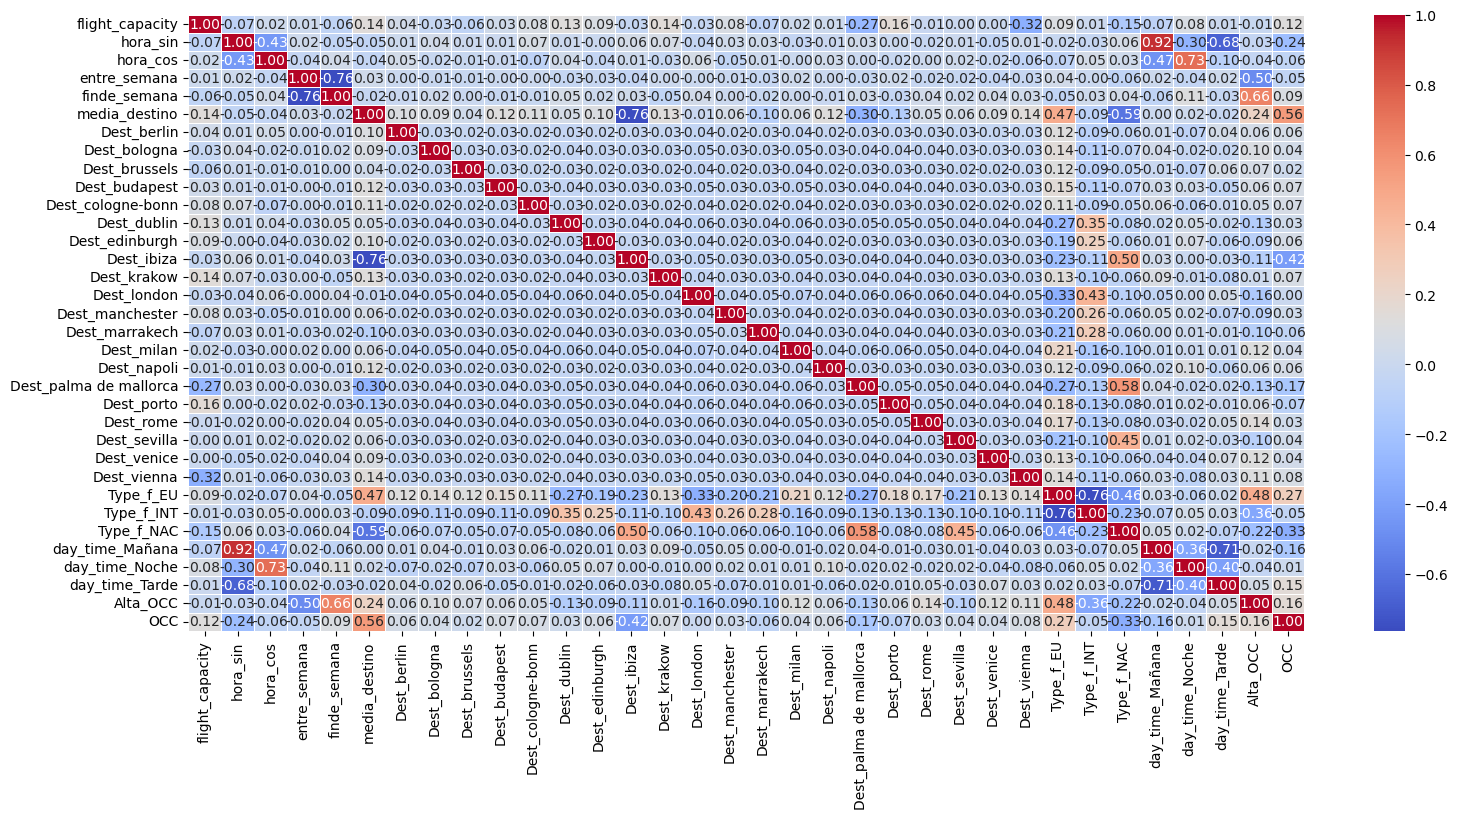

In [49]:
A = pd.concat([X_t, y], axis=1)

correlacion = A.corr()
plt.figure(figsize=(18,8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [50]:
#A.to_csv("EDA_occ.csv") 

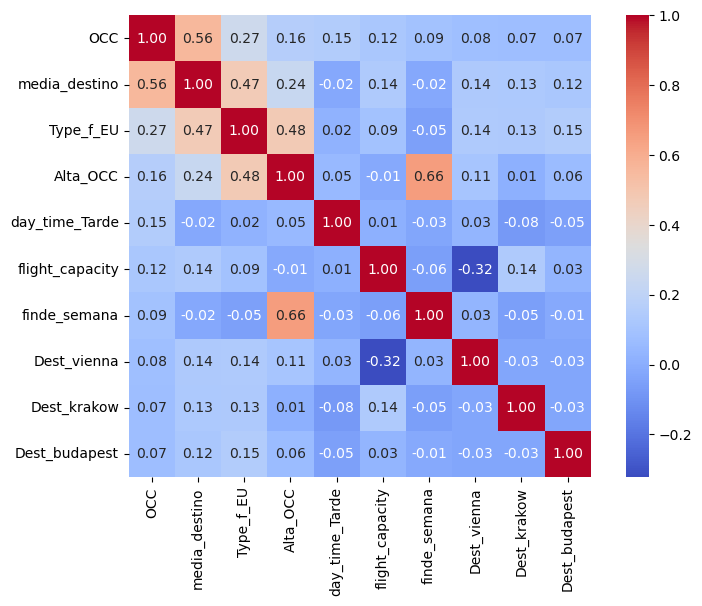

In [51]:
import numpy as np
import pandas as pd

k = 10 # número de variables
# 1. Obtener la lista de las 10 columnas más correlacionadas con 'OCC'
cols = correlacion.nlargest(k, 'OCC')['OCC'].index

# 2. SELECCIONAR el sub-DataFrame y CONVERTIRLO explícitamente a float para NumPy.
# Esto asegura que todos los datos sean float64 antes de calcular la transpuesta
matriz_datos = A[cols].astype(float).values.T

# 3. Calcular la matriz de correlación (ya no debería fallar)
cm = np.corrcoef(matriz_datos)

# 4. Visualización del heatmap
plt.figure(figsize=(9,6))
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
            annot_kws={'size': 10},
            yticklabels=cols.values, 
            xticklabels=cols.values,
            cmap="coolwarm")
plt.show()

## QUE AFECTA LA OCUPACION:
- **EL TIPO DE VUELO**; VUELOS EUROPEOS SUELEN IR MÁS LLENOS TAMBIÉN SON LOS MÁS FRECUENTES.
- **LA HORA DEL DÍA** NO ES LO MISMO UN VUELO DE 5 DE LA MAÑANA A LAS 10 O 17
- MÁS CORRELACIÓN **POR LA TARDE (12-20)** Y EN **FINDES DE SEMANA** (ASI COMO **LA CAPACIDAD**)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X_t, y, test_size=0.20, random_state=42)

In [53]:
from sklearn.ensemble import RandomForestRegressor

rt = RandomForestRegressor(
    n_estimators=500,     # número de árboles
    max_depth=10,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=12,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rt.fit(X_train, y_train)
y_pred_test = rt.predict(X_test)
y_pred_train = rt.predict(X_train)

rmse_rf_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rf= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rf_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rf= r2_score(y_test, y_pred_test) #medir performance real)

print(rmse_rf_tr)
print(rmse_rf)
print(r2_rf_tr)
print(r2_rf)

0.09374732608047463
0.08828938439074789
0.4970221528023868
0.4673542709440355


In [54]:
from sklearn.ensemble import RandomForestRegressor

rf_f = RandomForestRegressor(
    n_estimators=5000,     # número de árboles
    max_depth=9,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=9,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rf_f.fit(X_train, y_train)
y_pred_test = rf_f.predict(X_test)
y_pred_train = rf_f.predict(X_train)

rmse_rf_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rf= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rf_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rf= r2_score(y_test, y_pred_test) #medir performance real)

print(rmse_rf_tr)
print(rmse_rf)
print(r2_rf_tr)
print(r2_rf)

0.08752140755240233
0.08770087249597934
0.5616109821193851
0.47443153406085947


In [55]:
from sklearn.ensemble import RandomForestRegressor

rt = RandomForestRegressor(
    n_estimators=1000,     # número de árboles
    max_depth=4,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=11,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rt.fit(X_train, y_train)
y_pred_test = rt.predict(X_test)
y_pred_train = rt.predict(X_train)

rmse_rf_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rf= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rf_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rf= r2_score(y_test, y_pred_test) #medir performance real)

print(rmse_rf_tr)
print(rmse_rf)
print(r2_rf_tr)
print(r2_rf)

0.09217011254689594
0.08564764268419227
0.513804074927778
0.49875240701708756


In [56]:
from sklearn.ensemble import RandomForestRegressor

rt = RandomForestRegressor(
    n_estimators=1000,     # número de árboles
    max_depth=3,         # misma profundidad máxima que en el árbol individual
    min_samples_leaf=11,  # mismo tamaño mínimo de hoja
    n_jobs=-1,            # usa todos los núcleos del CPU
    random_state=42        # para reproducibilidad
)
#max_features-> seleccionar al azar la raiz de todas las var
rt.fit(X_train, y_train)
y_pred_test = rt.predict(X_test)
y_pred_train = rt.predict(X_train)

rmse_rf_tr= root_mean_squared_error(y_train, y_pred_train) #medir overfitting
rmse_rf= root_mean_squared_error(y_test, y_pred_test) #medir performance real)
r2_rf_tr= r2_score(y_train, y_pred_train) #medir overfitting
r2_rf= r2_score(y_test, y_pred_test) #medir performance real)

print(rmse_rf_tr)
print(rmse_rf)
print(r2_rf_tr)
print(r2_rf)

0.09350229540921971
0.08546213153071106
0.4996480183024339
0.5009214407976268


In [57]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV

n_cv = 3
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
)

# ===============================================================
# ESPACIO DE HIPERPARÁMETROS (puedes ajustarlo)
# ===============================================================
params = {
    #'max_depth': [4,5,6],# Maxima pofundidad del arbol
    "n_estimators":     [500,800,1000,2000],
    "max_depth":        [4,5,6,8],
    #Tamaño mínimo para dividir un nodo
    #"min_samples_split": [9, 10, 20, 40],
    # Tamaño mínimo de hoja 
   # "max_features": ['sqrt']  # o 0.5

    "min_samples_leaf": [8,10,12, 15],
    #Submuestreo de features por árbol → mejora generalización
    #"max_features": ["sqrt", "log2", 0.3, 0.4, None],
    # Submuestreo de datos,  reduce overfitting
    #"bootstrap": [True, False],
}
scoring = ['neg_mean_squared_error','r2']



# creamos la GridSeacrh
grid_solver = GridSearchCV(estimator = rf, # model to train RandomForestRegressor() 
                           param_grid = params, # param_grid
                           scoring = scoring,
                           cv = n_cv, # 3
                           refit = 'neg_mean_squared_error', # la metrica que va a usar para decidir el mejor modelo
                           verbose = 3) 

# ===============================================================
# ENTRENAR EL MODELO FINAL CON LOS MEJORES PARÁMETROS
# ===============================================================
grid_solver.fit(X_train, y_train)

best_params = grid_solver.best_params_
print("\n Mejores parámetros encontrados:")
print(best_params)

rf_final = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params
)

rf_final.fit(X_train, y_train)
y_pred = rf_final.predict(X_test)
y_predt = rf_final.predict(X_train)


# EVALUACIÓN FINAL EN TEST

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmset = np.sqrt(mean_squared_error(y_train, y_predt))
r2 = r2_score(y_test, y_pred)
r2t = r2_score(y_train, y_predt)

print("\n== RANDOM-FOREST (Optimizado) ==")
print("RMSE_test:", round(rmse, 4)) #medir performance real
print("RMSE_train:", round(rmset, 4)) #medir overfitting
print("R2_test:", round(r2, 4)) #medir performance real
print("R2_train:", round(r2t, 4)) #medir overfitting

#max_features-> seleccionar al azar la raiz de todas las var


Fitting 3 folds for each of 64 candidates, totalling 192 fits
[CV 1/3] END max_depth=4, min_samples_leaf=8, n_estimators=500; neg_mean_squared_error: (test=-0.010) r2: (test=0.498) total time=   0.5s
[CV 2/3] END max_depth=4, min_samples_leaf=8, n_estimators=500; neg_mean_squared_error: (test=-0.012) r2: (test=0.297) total time=   0.6s
[CV 3/3] END max_depth=4, min_samples_leaf=8, n_estimators=500; neg_mean_squared_error: (test=-0.008) r2: (test=0.435) total time=   0.5s
[CV 1/3] END max_depth=4, min_samples_leaf=8, n_estimators=800; neg_mean_squared_error: (test=-0.010) r2: (test=0.503) total time=   0.9s
[CV 2/3] END max_depth=4, min_samples_leaf=8, n_estimators=800; neg_mean_squared_error: (test=-0.012) r2: (test=0.300) total time=   1.0s
[CV 3/3] END max_depth=4, min_samples_leaf=8, n_estimators=800; neg_mean_squared_error: (test=-0.008) r2: (test=0.440) total time=   0.9s
[CV 1/3] END max_depth=4, min_samples_leaf=8, n_estimators=1000; neg_mean_squared_error: (test=-0.010) r2: (te

In [58]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",        # o "gpu_hist" si tienes GPU
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# ===============================================================
# ESPACIO DE HIPERPARÁMETROS (puedes ajustarlo)
# ===============================================================
param_dist = {
    "n_estimators": [500,800, 10000, 2000], 
    
    # Profundidad baja para evitar memorizar datos
    "max_depth": [4, 5, 7, 9],
    
    # Bajar esto es la mejor forma de combatir el overfitting en XGBoost
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
    
    # Submuestreo de filas y columnas más agresivo
    #"subsample": [0.5, 0.6, 0.7], 
    #"colsample_bytree": [0.5, 0.6, 0.7, 0.8],
    
    # Mantener el peso de la hoja o ajustarlo
    "min_child_weight": [5, 6, 8, 10], 
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=100,                              # número de combinaciones a probar
    scoring="neg_root_mean_squared_error",  # RMSE (negativo por convención sklearn)
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# ===============================================================
# ENTRENAR EL MODELO FINAL CON LOS MEJORES PARÁMETROS
# ===============================================================
search.fit(X_train, y_train)

print("\n Mejores hiperparámetros encontrados:")
print(search.best_params_)
print("RMSE CV:", round(-search.best_score_, 4))

best_params = search.best_params_

xgb_final = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",      
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)
y_predt = xgb_final.predict(X_train)


# EVALUACIÓN FINAL EN TEST

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmset = np.sqrt(mean_squared_error(y_train, y_predt))
r2 = r2_score(y_test, y_pred)
r2t = r2_score(y_train, y_predt)

print("\n== XGBOOST (Optimizado) ==")
print("RMSE_test:", round(rmse, 4)) #medir performance real
print("RMSE_train:", round(rmset, 4)) #medir overfitting
print("R2_test:", round(r2, 4)) #medir performance real
print("R2_train:", round(r2t, 4)) #medir overfitting

#max_features-> seleccionar al azar la raiz de todas las var


Fitting 5 folds for each of 100 candidates, totalling 500 fits

 Mejores hiperparámetros encontrados:
{'n_estimators': 800, 'min_child_weight': 8, 'max_depth': 4, 'learning_rate': 0.005}
RMSE CV: 0.0869

== XGBOOST (Optimizado) ==
RMSE_test: 0.1005
RMSE_train: 0.0654
R2_test: 0.3105
R2_train: 0.7551


In [59]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",        # o "gpu_hist" si tienes GPU
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# ===============================================================
# ESPACIO DE HIPERPARÁMETROS (puedes ajustarlo)
# ===============================================================
param_dist = {
    "n_estimators": [70, 500, 800, 1000], 
    
    # Profundidad baja para evitar memorizar datos
    "max_depth": [4, 5, 6, 7],
    
    # Bajar esto es la mejor forma de combatir el overfitting en XGBoost
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
    
    # Submuestreo de filas y columnas más agresivo
    #"subsample": [0.5, 0.6, 0.7], 
    #"colsample_bytree": [0.5, 0.6, 0.7, 0.8],
    
    # Mantener el peso de la hoja o ajustarlo
    "min_child_weight": [5, 6, 8, 10], 
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=500,                              # número de combinaciones a probar
    scoring="neg_root_mean_squared_error",  # RMSE (negativo por convención sklearn)
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# ===============================================================
# ENTRENAR EL MODELO FINAL CON LOS MEJORES PARÁMETROS
# ===============================================================
search.fit(X_train, y_train)

print("\n Mejores hiperparámetros encontrados:")
print(search.best_params_)
print("RMSE CV:", round(-search.best_score_, 4))

best_params = search.best_params_

xgb_final = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",      
    random_state=42,
    n_jobs=-1,
    **best_params
)

xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)
y_predt = xgb_final.predict(X_train)


# EVALUACIÓN FINAL EN TEST

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmset = np.sqrt(mean_squared_error(y_train, y_predt))
r2 = r2_score(y_test, y_pred)
r2t = r2_score(y_train, y_predt)

print("\n== XGBOOST (Optimizado) ==")
print("RMSE_test:", round(rmse, 4)) #medir performance real
print("RMSE_train:", round(rmset, 4)) #medir overfitting
print("R2_test:", round(r2, 4)) #medir performance real
print("R2_train:", round(r2t, 4)) #medir overfitting

#max_features-> seleccionar al azar la raiz de todas las var


Fitting 5 folds for each of 320 candidates, totalling 1600 fits


C:\Users\linap\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 320 is smaller than n_iter=500. Running 320 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



 Mejores hiperparámetros encontrados:
{'n_estimators': 800, 'min_child_weight': 8, 'max_depth': 4, 'learning_rate': 0.005}
RMSE CV: 0.0869

== XGBOOST (Optimizado) ==
RMSE_test: 0.1005
RMSE_train: 0.0654
R2_test: 0.3105
R2_train: 0.7551


In [60]:
modelo_entero= rt.fit(X_t,y)
# entreno el modelo con el modelo elegido y toda la x y y de la tabla pequeña

In [61]:
x = df_gr.drop(columns=["OCC"]) # la nueva x 
#Y = df_gr.OCC # la nueva y 

In [62]:
X_f, encoder, label_encoders, top_destinos = transforma_datos(x,
    encoder=encoder,
    label_encoders=label_encoders,
    top_destinos=top_destinos,                                       
    media_destino_map=media_destino_map,
    global_media=global_media,
    ajustar_encoders=False) # NO AJUSTAR SOLO TRANSFORMAR CON LO AJUSTADO  
                                                              

In [63]:
y_hat = rt.predict(X_f)
# transformo la nueva x y la llamo x_f y testeo en ella con el modelo elegido 

In [64]:
y_hat

array([0.94648746, 0.94647694, 0.82432482, ..., 0.91526831, 0.94664863,
       0.87279412])

In [65]:
df_gr['OCC_pred'] = y_hat.round(2)

In [66]:
df_gr

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,OCC,OCC_pred
0,2025-11-17,FR3180,rome,06:00:00,189,EU,Lunes,Mañana,NaN,0.95
1,2025-11-17,FR846,milan,06:10:00,189,EU,Lunes,Mañana,NaN,0.95
2,2025-11-17,FR2233,al aaroui,06:20:00,189,INT,Lunes,Mañana,NaN,0.82
3,2025-11-17,FR8384,budapest,06:25:00,189,EU,Lunes,Mañana,NaN,0.98
4,2025-11-17,FR3078,lisbon,06:30:00,189,EU,Lunes,Mañana,NaN,0.98
...,...,...,...,...,...,...,...,...,...,...
1271,2025-12-07,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,0.94,0.92
1272,2025-12-07,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,1.00,0.96
1273,2025-12-07,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0.94,0.92
1274,2025-12-07,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,1.00,0.95


In [67]:
df_gr[(df_gr['fecha_scrapeo'] == '2025-11-23')]

,fecha_scrapeo,Num_flight,Name_Destiny,Time_flight,flight_capacity,Type_f,week_day,day_time,OCC,OCC_pred
345,2025-11-23,FR3180,rome,06:00:00,189,EU,Domingo,Mañana,0.96,0.95
346,2025-11-23,FR2834,charleroi,06:10:00,197,EU,Domingo,Mañana,0.94,0.95
347,2025-11-23,FR2918,brussels,06:25:00,189,EU,Domingo,Mañana,0.94,0.95
348,2025-11-23,FR4084,warsaw,06:25:00,189,EU,Domingo,Mañana,0.99,0.98
349,2025-11-23,FR2239,marrakech,06:30:00,189,INT,Domingo,Mañana,0.87,0.80
...,...,...,...,...,...,...,...,...,...,...
417,2025-11-23,FR2896,palma de mallorca,21:15:00,189,NAC,Domingo,Noche,1.00,0.92
418,2025-11-23,FR3792,birmingham,21:20:00,189,INT,Domingo,Noche,0.92,0.96
419,2025-11-23,FR5752,valletta,21:45:00,197,EU,Domingo,Noche,0.94,0.92
420,2025-11-23,FR5220,bologna,22:50:00,189,EU,Domingo,Noche,0.99,0.95


In [68]:
df_gr.to_csv("Tabla_vuelos_ryr_occ.csv") 